# KNN Classification - Breast Cancer Wisconsin Dataset

Build a K-Nearest Neighbors classification model to predict whether a breast tumor is **benign (Class 2)** or **malignant (Class 4)** using the Breast Cancer Wisconsin dataset. You are given pre-loaded training and test data. Train a KNN model on the training data, predict on the test data, and store the predictions in the required format.

---

**Tasks:**

1. **Preprocess:** Drop the `ID` column and separate features from labels in the training data
2. **Train:** Fit a KNN classifier on the training data
3. **Predict:** Generate class predictions for the test data
4. **Submit:** Create a `submission_df` DataFrame with columns `ID` and `Class`

---

**Expected Variables:**

| Variable | Type | Description |
|---|---|---|
| `submission_df` | pandas DataFrame | DataFrame with columns `ID` (int) and `Class` (2 or 4), one row per test sample |

In [70]:
# Run this cell before writing your solution

import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

train_url = "https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/Breast_Cancer_Wisconsin_Dataset.csv"
test_url  = "https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/Breast_cancer_test_data.csv"

train_data = pd.read_csv(train_url)
test_data  = pd.read_csv(test_url)

print(f"Train shape: {train_data.shape}")
print(f"Test shape:  {test_data.shape}")
print(f"Train columns: {train_data.columns.tolist()}")
print(f"Test columns:  {test_data.columns.tolist()}")

Train shape: (558, 11)
Test shape:  (81, 10)
Train columns: ['ID', 'Clump_Thickness', 'Cell_Size_Uniformity', 'Cell_Shape_Uniformity', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']
Test columns:  ['ID', 'Clump_Thickness', 'Cell_Size_Uniformity', 'Cell_Shape_Uniformity', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']


In [71]:
# Write your code here
original_test_data = train_data
train_data.head()

,ID,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1188472,1,1,1,1,1,1,3,1,1,2
1,1223793,6,10,7,7,6,4,8,10,2,4
2,1174057,4,2,1,1,2,2,3,1,1,2
3,706426,5,5,5,2,5,10,4,3,1,4
4,1131411,1,1,1,2,2,1,2,1,1,2


In [72]:
train_data.shape

(558, 11)

In [73]:
train_data.head()

,ID,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1188472,1,1,1,1,1,1,3,1,1,2
1,1223793,6,10,7,7,6,4,8,10,2,4
2,1174057,4,2,1,1,2,2,3,1,1,2
3,706426,5,5,5,2,5,10,4,3,1,4
4,1131411,1,1,1,2,2,1,2,1,1,2


In [74]:
train_data.isna().sum()
ids = test_data["ID"]

In [75]:
X = train_data.drop(columns=['Class',"ID"])
y = train_data['Class']

In [76]:
X

,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,1,1,1,1,1,1,3,1,1
1,6,10,7,7,6,4,8,10,2
2,4,2,1,1,2,2,3,1,1
3,5,5,5,2,5,10,4,3,1
4,1,1,1,2,2,1,2,1,1
...,...,...,...,...,...,...,...,...,...
553,7,4,6,4,6,1,4,3,1
554,3,1,1,1,2,1,3,1,1
555,5,6,5,6,10,1,3,1,1
556,5,1,1,1,2,1,1,1,1


In [77]:
y

0      2
1      4
2      2
3      4
4      2
      ..
553    4
554    2
555    4
556    2
557    2
Name: Class, Length: 558, dtype: int64

In [78]:
!pip install -U seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [79]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
model.fit(X,y)

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[2,4]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [80]:
model.score(X,y)

0.974910394265233

In [81]:

scores = []
for i in range(1,40):
  knn = KNeighborsClassifier(n_neighbors=i,metric="euclidean")
  knn.fit(X,y)
  scores.append(knn.score(X,y))

In [82]:
import seaborn as sns 
import matplotlib.pyplot as plt 

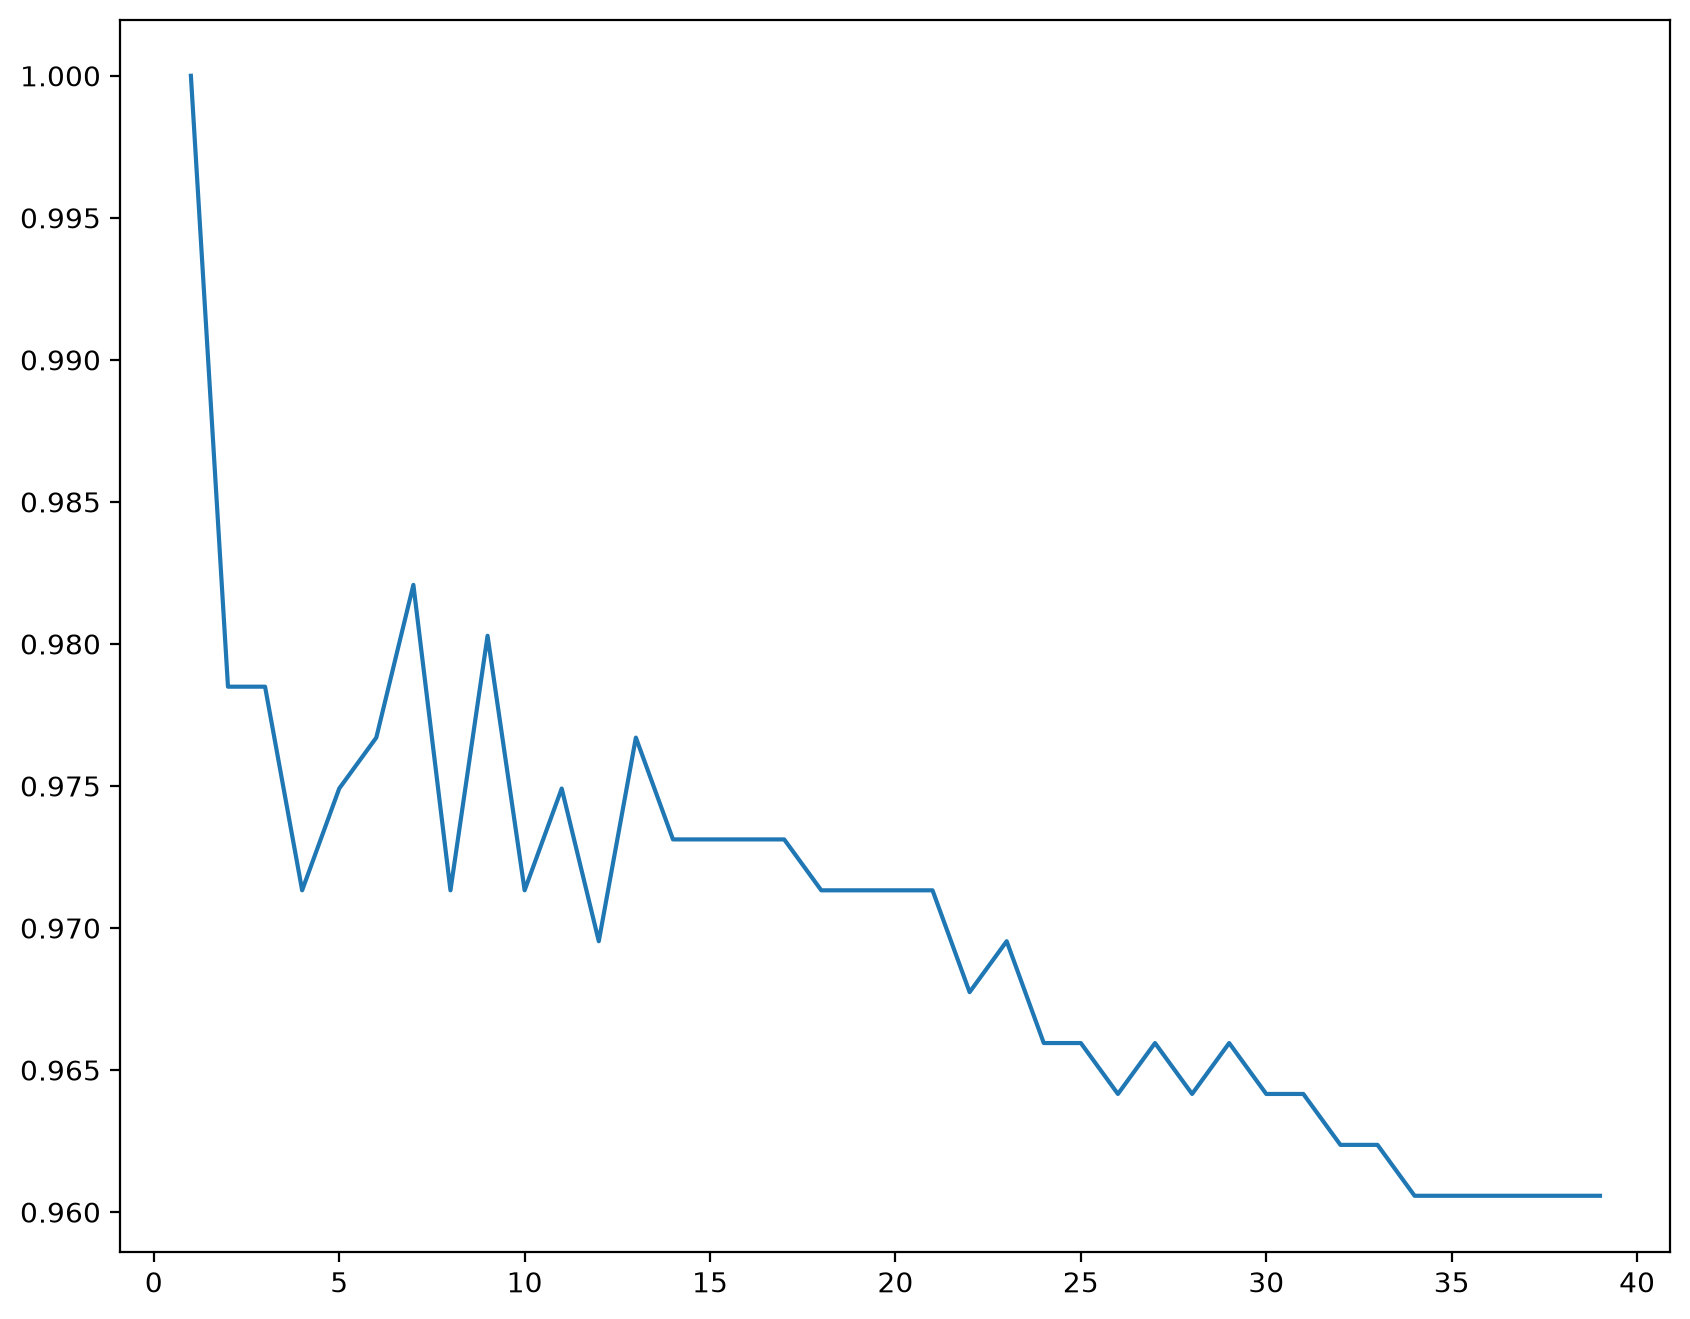

In [83]:
plt.figure(figsize=(10,8),dpi=200)
plt.plot(range(1,40),scores)
plt.show()

In [84]:
final_model = KNeighborsClassifier(n_neighbors=15,metric="euclidean")
final_model.fit(X,y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[2,4]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [85]:
test_data.head()

,ID,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,76389,10,4,7,2,2,8,6,1,1
1,142932,7,6,10,5,3,10,9,10,2
2,183913,1,2,2,1,2,1,1,1,1
3,255644,10,5,8,10,3,10,5,1,3
4,263538,5,10,10,6,10,10,10,6,5


In [86]:
test_data = test_data.drop(columns=['ID'])

In [87]:
model.predict(test_data)

array([4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 4, 4, 2, 2, 2, 4, 2, 2, 4, 2, 2, 2,
       4, 2, 2, 4, 2, 4, 4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 4, 2, 2, 4, 4, 2,
       2, 2, 2, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 2,
       4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2])

In [88]:
final_model.predict(test_data)

array([4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 4, 4, 2, 2, 2, 4, 2, 2, 4, 2, 2, 2,
       4, 4, 2, 4, 2, 4, 4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 4, 2, 2, 4, 4, 2,
       2, 2, 2, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 2,
       4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2])

In [89]:
!pip install -U pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [90]:
original_test_data.head()

,ID,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1188472,1,1,1,1,1,1,3,1,1,2
1,1223793,6,10,7,7,6,4,8,10,2,4
2,1174057,4,2,1,1,2,2,3,1,1,2
3,706426,5,5,5,2,5,10,4,3,1,4
4,1131411,1,1,1,2,2,1,2,1,1,2


In [91]:
import pandas as pd

In [92]:
predictions = final_model.predict(test_data)
print(predictions)

[4 4 2 4 4 2 4 2 4 4 4 4 2 2 2 4 2 2 4 2 2 2 4 4 2 4 2 4 4 4 2 4 2 4 4 2 4
 4 4 2 2 4 4 2 2 2 2 2 4 2 4 2 4 2 4 2 4 2 2 4 2 2 2 2 2 2 4 4 2 2 2 2 2 2
 2 2 4 2 2 4 2]


In [93]:
submission_df = pd.DataFrame({
    'ID': ids,
    'Class': predictions
})

In [94]:
submission_df.name = "ID"

In [95]:
print(submission_df)

         ID  Class
0     76389      4
1    142932      4
2    183913      2
3    255644      4
4    263538      4
..      ...    ...
76  1318169      4
77  1324681      2
78  1368273      2
79  1369821      4
80  1371920      2

[81 rows x 2 columns]
